# Abitibi dykes ca. 1141 Ma paleomagnetic pole

## Geologic context

The Abitibi dykes are northeast-trending diabase dykes of the southern Superior
Province (Ontario/Quebec) emplaced ca. 1141 Ma that predates the initiation of
the Midcontinent Rift ca. 1109 Ma (Ernst & Buchan, 1993). A U-Pb baddeleyite age
of 1140.6 ± 2 Ma (Krogh, 1987) dates the dykes. The dykes carry a steep,
dominantly down-to-the-northwest magnetization of mixed polarity. It being a
primary thermal remanent magnetization is supported by a positive baked-contact
test.

## Pole

This notebook recreates the Abitibi pole at the dyke level from the per-dyke mean
directions of Ernst & Buchan (1993), recomputing signed VGPs. The dataset is
updated to the eight-dyke group of Halls et al. (2005): the original A1 dyke is
reassigned to the ca. 2167 Ma Biscotasing swarm and excluded, and a new
normal-polarity dyke (SL13) is added.

## Age Constraints
A U-Pb baddeleyite age of 1140.6 ± 2 Ma (Krogh, 1987) dates the dykes. 

## References
- Paleomagnetic source: Ernst, R. E., & Buchan, K. L. (1993). Paleomagnetism of the Abitibi dyke swarm, southern Superior Province, and implications for the Logan Loop. Canadian Journal of Earth Sciences, 30(9), 1886–1897. https://doi.org/10.1139/e93-167

- Geochronology / age-constraint note (compilation): Krogh, T., Corfu, F., Davis, D., Dunning, G., Heaman, L., Kamo, S., Machado, N., Greenough, J., & Nakamura, E. (1987). Precise U–Pb isotopic ages of diabase dykes and mafic to ultramafic rocks using trace amounts of baddeleyite and zircon. Mafic Dyke Swarms. Edited by HC Halls and WF Fahrig. Geological Association of Canada, Special Paper, 34, 147–152.


In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data and the eight-dyke pole

The contribution holds individual site results and per-dyke means
(`result_type == 'a'`). The pole uses the eight dyke means — A3-A8 plus the
Halls et al. (2005) dyke SL13 that was published after the Ernst & Buchan (1993) and excluding A1 (reassigned to the Biscotasing swarm). Dykes A4 and A7 carry reversed polarity.

In [2]:
sites = pd.read_csv('../data/1141_Abitibi/sites.txt', sep='\t', skiprows=1)
dykes = sites[(sites['result_type'] == 'a') & (sites['site'] != 'A1')].reset_index(drop=True)
study_lat, study_lon = 48.0, 279.0
print(f'{len(dykes)} dyke means for the pole:', dykes['site'].tolist())
print('reversed-polarity dykes:', dykes[dykes['dir_inc'] < 0]['site'].tolist())
dykes[['site', 'dir_dec', 'dir_inc', 'dir_k', 'dir_alpha95', 'dir_n_samples', 'vgp_lat', 'vgp_lon']]

8 dyke means for the pole: ['A3', 'A4', 'A5', 'A6_1', 'A6_2', 'A7', 'A8', 'SL13']
reversed-polarity dykes: ['A4', 'A7']


,site,dir_dec,dir_inc,dir_k,dir_alpha95,dir_n_samples,vgp_lat,vgp_lon
0,A3,298.3,52.4,NaN,NaN,2,42.1,194.3
1,A4,126.4,-71.5,NaN,NaN,2,-57.0,43.8
2,A5,310.5,59.1,72.0,10.9,4,54.1,194.7
3,A6_1,283.1,57.2,153.0,6.2,5,35.1,208.8
4,A6_2,302.7,70.9,189.0,4.4,7,54.8,222.9
5,A7,146.2,-80.7,NaN,NaN,2,-61.6,77.7
6,A8,264.9,60.1,68.0,9.4,5,26.3,222.0
7,SL13,315.9,62.7,61.0,5.1,1,59.6,194.1


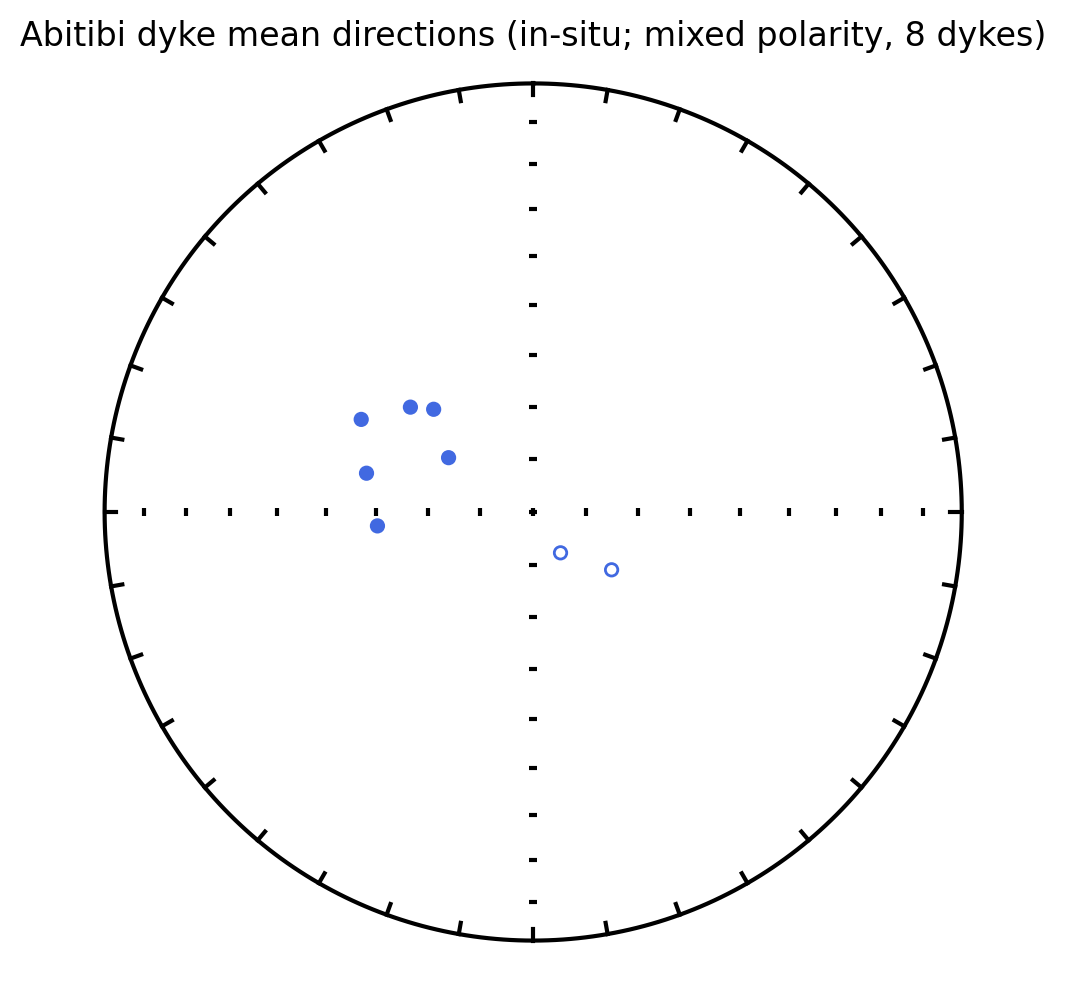

Plon: 213.4  Plat: 50.4
Number of directions in mean (n): 8
Angular radius of 95% confidence (A_95): 12.6
Precision parameter (k) estimate: 20.3

Halls et al. (2005) / Piispa et al. (2018) modified pole: 50.5 N / 213.8 E, A95 12.5, N=8
original Ernst & Buchan (1993) pole (GPMDB 7193): 48.8 N / 215.5 E, A95 14.1, N=7


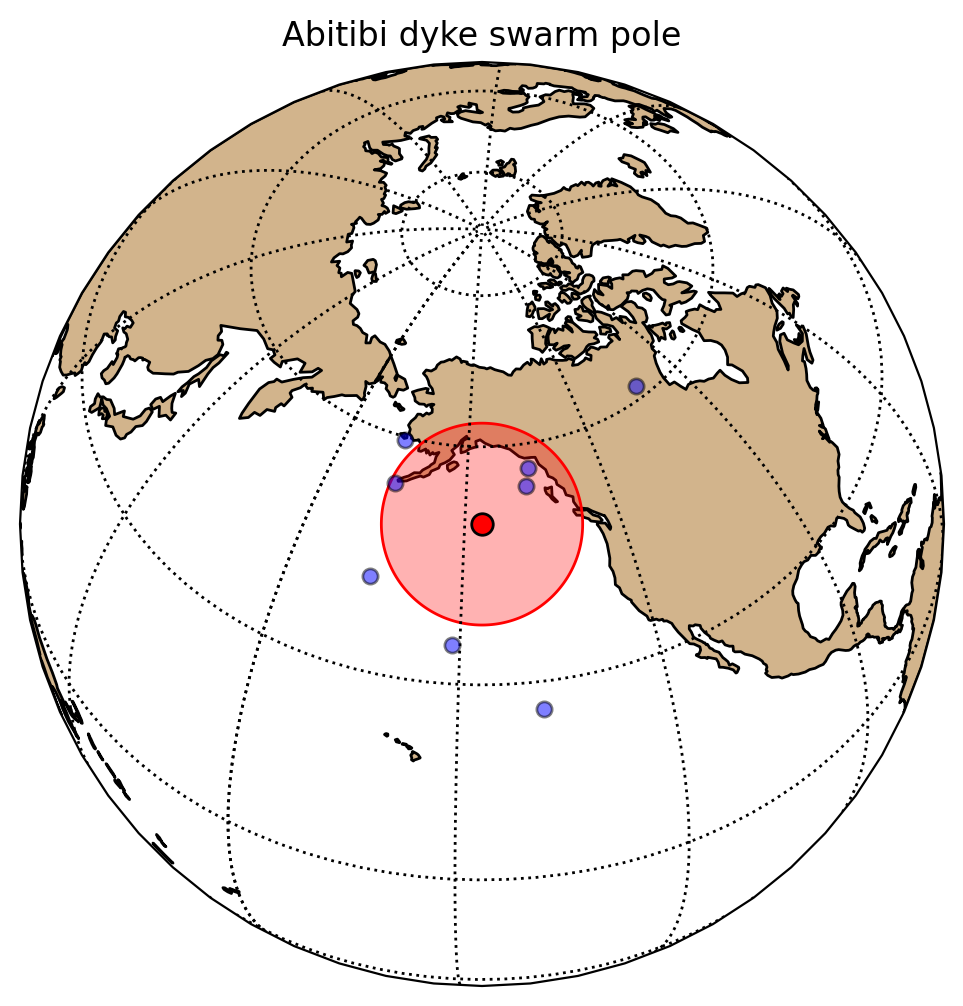

In [3]:
ipmag.plot_net()
ipmag.plot_di(dykes['dir_dec'].tolist(), dykes['dir_inc'].tolist(), color='royalblue', marker='o')
plt.title('Abitibi dyke mean directions (in-situ; mixed polarity, 8 dykes)')
plt.show()

vgp_block, pole_mean = pt.compute_mean_pole(dykes, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
print('\nHalls et al. (2005) / Piispa et al. (2018) modified pole: 50.5 N / 213.8 E, A95 12.5, N=8')
print('original Ernst & Buchan (1993) pole (GPMDB 7193): 48.8 N / 215.5 E, A95 14.1, N=7')
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('Abitibi dyke swarm pole')
plt.show()

## The Halls et al. (2005) revision

Ernst & Buchan (1993) based their group-mean pole on five normally and two
reversely magnetized dykes, with two independent normal directions obtained from
distinct lithological units of the Great Abitibi Dike (site A6). The primary
nature of the normal-polarity directions was established by a baked-contact test
against a Matachewan dyke, and the presence of opposite-polarity directions in
neighbouring dykes argued against pervasive regional remagnetization. The
reversed-polarity directions are steeper than their normal counterparts, so the
primary origin of the reversed remanence remains somewhat tentative (Ernst &
Buchan, 1993; Piispa et al., 2018).

Subsequently, one of the normal-polarity dykes (A1) was shown to belong to the
ca. 2167 Ma Biscotasing swarm, and a new normal-polarity Abitibi dyke direction
was reported (Halls et al., 2005). With A1 removed and the new dyke (SL13, here
taken from Piispa et al., 2018, Table 3) added, the modified group-mean direction
is D = 297.4°, I = 65.5° (α95 = 8.3°, N = 8), corresponding to a pole at
50.5°N, 213.8°E (A95 = 12.5°) — offset ~8.5° from the original Ernst & Buchan
(1993) pole (Halls et al., 2005; Piispa et al., 2018). This notebook adopts that
revised eight-dyke dataset, and the recreated pole above reproduces it.

In [4]:
dir_block, dir_mean = pt.compute_mean_direction(dykes, unify_polarity=True)
ipmag.print_direction_mean(dir_mean)

Dec: 297.9  Inc: 65.3
Number of directions in mean (n): 8
Angular radius of 95% confidence (a_95): 8.4
Precision parameter (k) estimate: 44.2


## Reversal test (McFadden & McElhinny, 1990)

The swarm carries six normal-polarity dykes (A3, A5, A6_1, A6_2, A8, SL13) and
two reversed-polarity dykes (A4, A7). The McFadden & McElhinny (1990) reversal
test inverts the reversed group to normal polarity and applies a Watson V
common-mean test, returning a classification (A/B/C) or a negative/indeterminate
result. The two reversed dykes are steeper than the normal group, so the means
remain distinguishable and the test is negative/indeterminate at this resolution;
the presence of both polarities nonetheless documents that the swarm records
reversals (Meert R6).

normal-polarity dykes  : ['A3', 'A5', 'A6_1', 'A6_2', 'A8', 'SL13']
reversed-polarity dykes: ['A4', 'A7']
Results of Watson V test: 

Watson's V:           10.8
Critical value of V:  9.2
"Fail": Since V is greater than Vcrit, the two means can
be distinguished at the 95% confidence level.

M&M1990 classification:

Angle between data set means: 15.9
Critical angle for M&M1990:   14.7


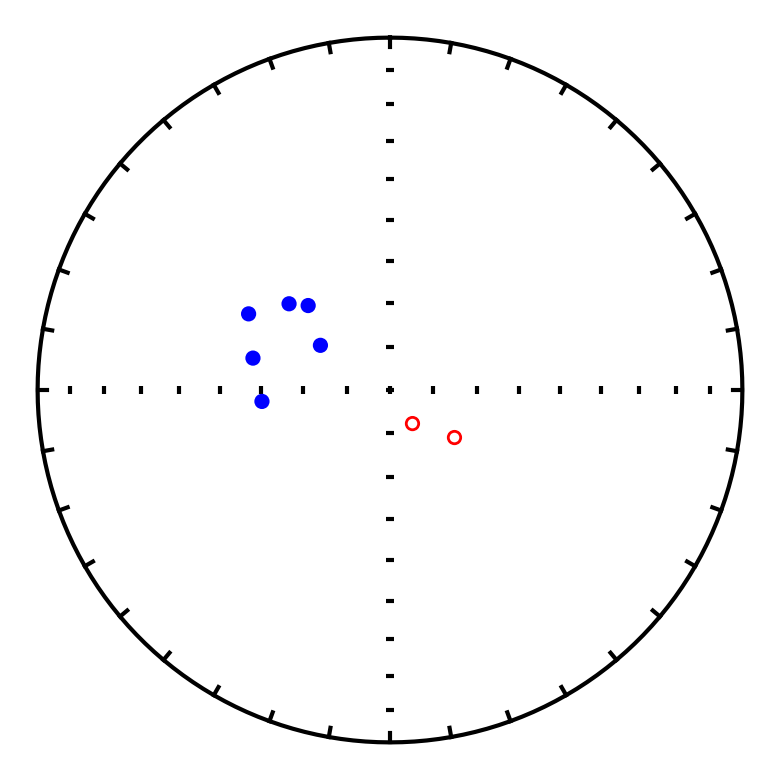

In [5]:
print('normal-polarity dykes  :', dykes[dykes['dir_inc'] > 0]['site'].tolist())
print('reversed-polarity dykes:', dykes[dykes['dir_inc'] < 0]['site'].tolist())

# McFadden & McElhinny (1990) reversal test: Watson V common-mean test + classification
ipmag.reversal_test_MM1990(dec=dykes['dir_dec'].tolist(), inc=dykes['dir_inc'].tolist(),
                           plot_stereo=True)
plt.show()

### Bootstrap common-mean reversal test (Tauxe)

As an independent check, the bootstrap common-mean reversal test resamples the
normal-polarity group and the inverted reversed-polarity group and compares the
Cartesian components of their means; the test is positive when the 95% bootstrap
confidence bounds of the two means overlap on all three axes. As with the
McFadden & McElhinny (1990) test above, the small, steeper reversed group
(A4, A7) leaves the two means distinguishable, so the result is
negative/indeterminate — consistent with the steeper reversed directions noted by
Ernst & Buchan (1993) and Piispa et al. (2018). Both polarities are nonetheless
present, so the swarm records reversals (Meert R6).

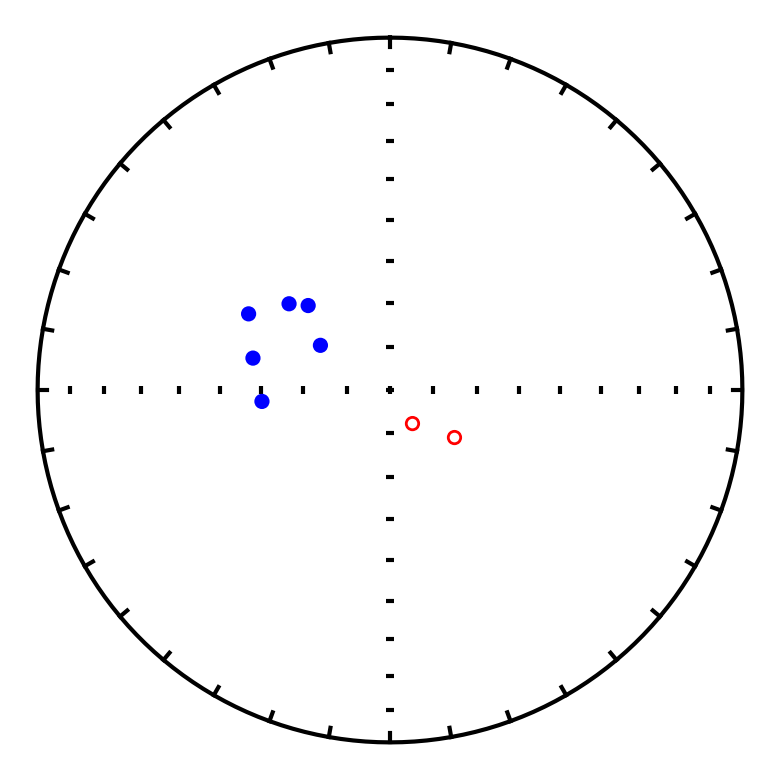

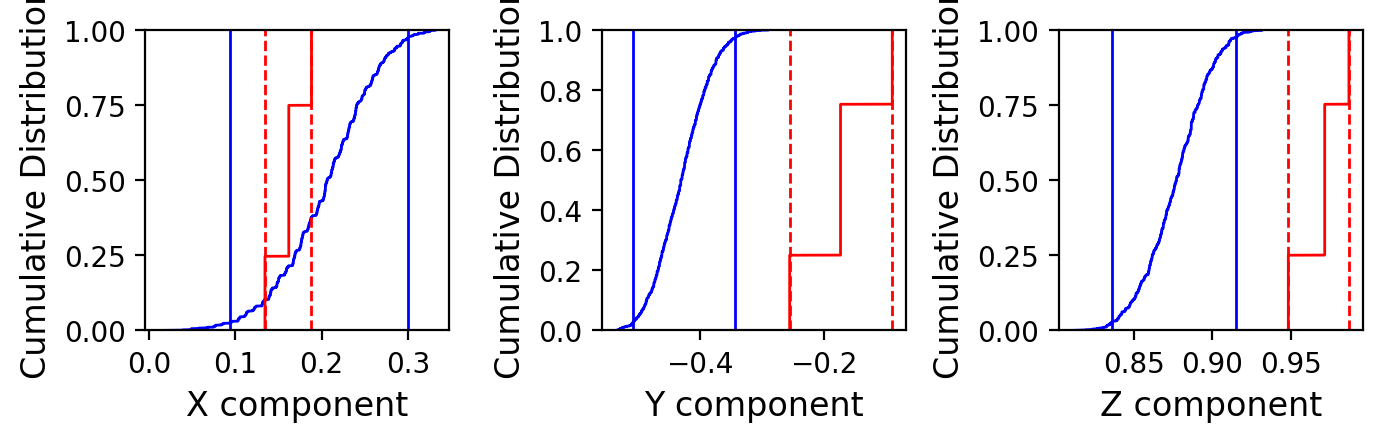

Fail, distinct in y and z


In [6]:
ipmag.reversal_test_bootstrap(dec=dykes['dir_dec'].tolist(), inc=dykes['dir_inc'].tolist(),
                              plot_stereo=True, random_seed=23)
plt.show()

## Field test: baked contact

The swarm includes baked host-rock margins (sites A6_2-16B, A6_2-21B) that carry
the dyke direction, while the unbaked host away from the contact (A6_2-16U,
A6_2-21U) carries a distinct shallow direction — a positive baked-contact test.

In [7]:
bc = sites[sites['site'].isin(['A6_2-16B', 'A6_2-16U', 'A6_2-21B', 'A6_2-21U'])]
print(bc[['site', 'dir_dec', 'dir_inc', 'dir_alpha95', 'description']].to_string(index=False) if len(bc) else 'baked-contact rows not present')

    site  dir_dec  dir_inc  dir_alpha95                                                                                                     description
A6_2-16B    310.0     66.3          8.3    Baked host rock for site 16 (dyke A6 unit 2): location here is from site 16: age from Heaman and Tarney 1989
A6_2-16U    218.6    -15.7         18.2  Unbaked host rock for site 16 (dyke A6 unit 2): location here is from site 16: age from Heaman and Tarney 1989
A6_2-21B    295.3     75.6          1.6                                   Baked host rock for site 21 (dyke A6 unit 2): age from Heaman and Tarney 1989
A6_2-21U    212.9     -9.2          7.5 Unbaked host rock for site 21 (dyke A6 unit 2): location here is from site 21B: age from Heaman and Tarney 1989


## Paleosecular variation

A_95 of 12.6 passes Deenen et al. (2011) criteria of being between 5.2 and 22.1 for this number of sites


<Axes: title={'center': 'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

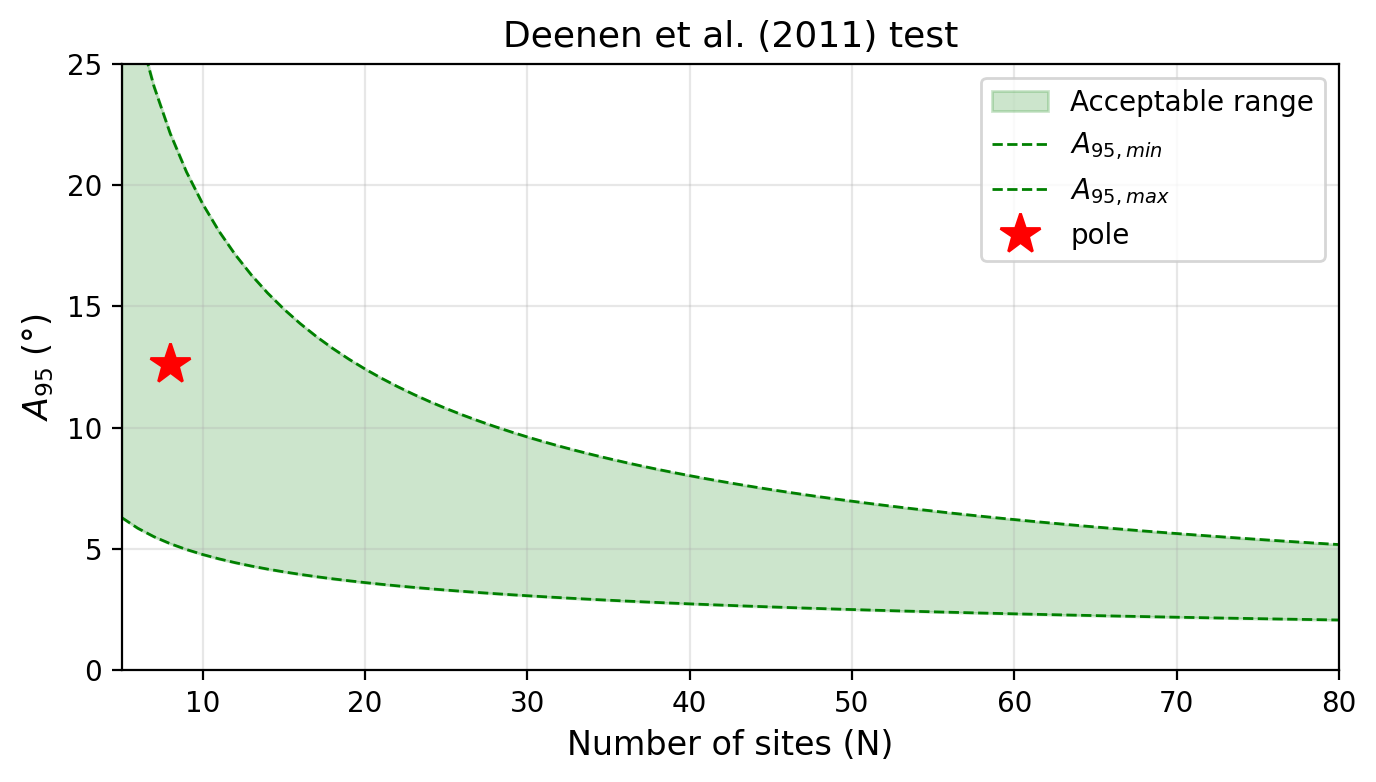

In [8]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)

## Paleosecular variation and VGP-shape diagnostics

The Fisher-quantile (fishqq) test assesses whether the site VGPs are drawn from a
Fisher distribution, and the shape-elongation/inclination (SVEI) test compares the
VGP-scatter elongation against the TK03.GAD paleosecular-variation model expectation
at the sampling paleolatitude.

In [9]:
fishqq_result = pt.fishqq_vgps(dykes, unify_polarity=True)
fishqq_result

you need N> 10 for at least one mode


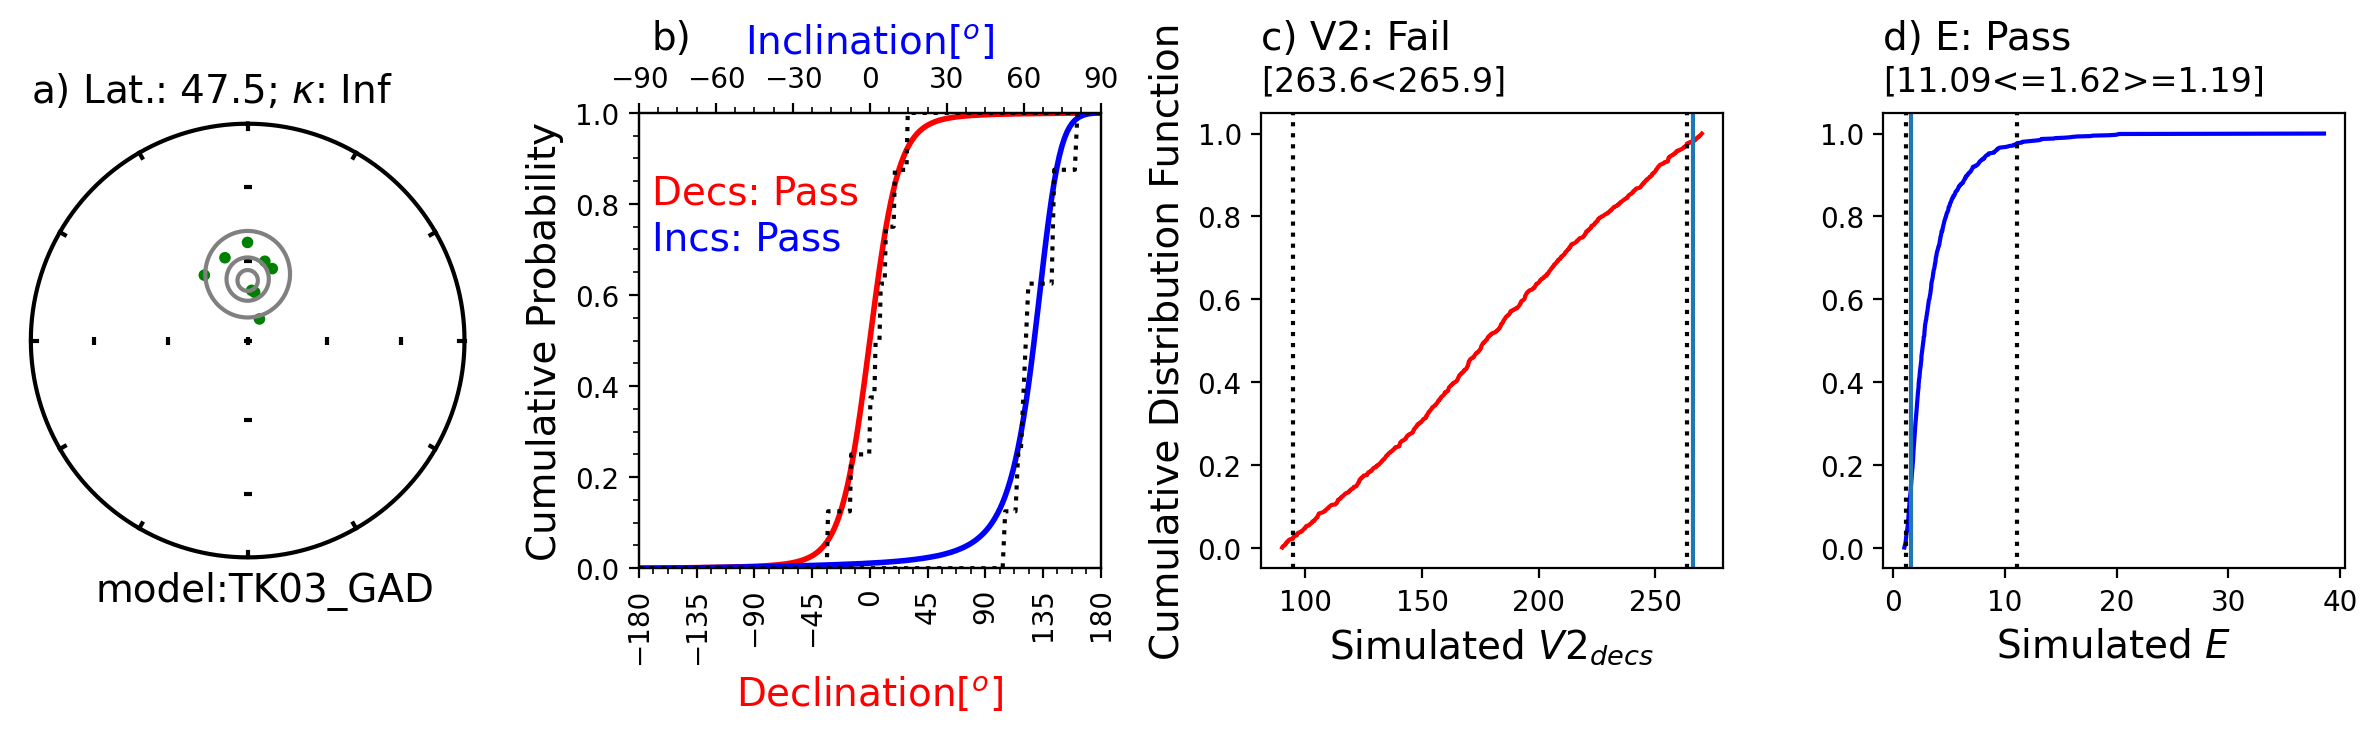

paleolatitude = 47.5 deg; elongation E = 1.62 (consistent with TK03.GAD)


In [10]:
_slat, _slon = float(dykes['lat'].mean()), float(dykes['lon'].mean())
try:
    svei_result = pt.svei_test_vgps(dykes, _slon, _slat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(dykes, _slon, _slat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## The Abitibi pole in the context of the Laurentia APWP

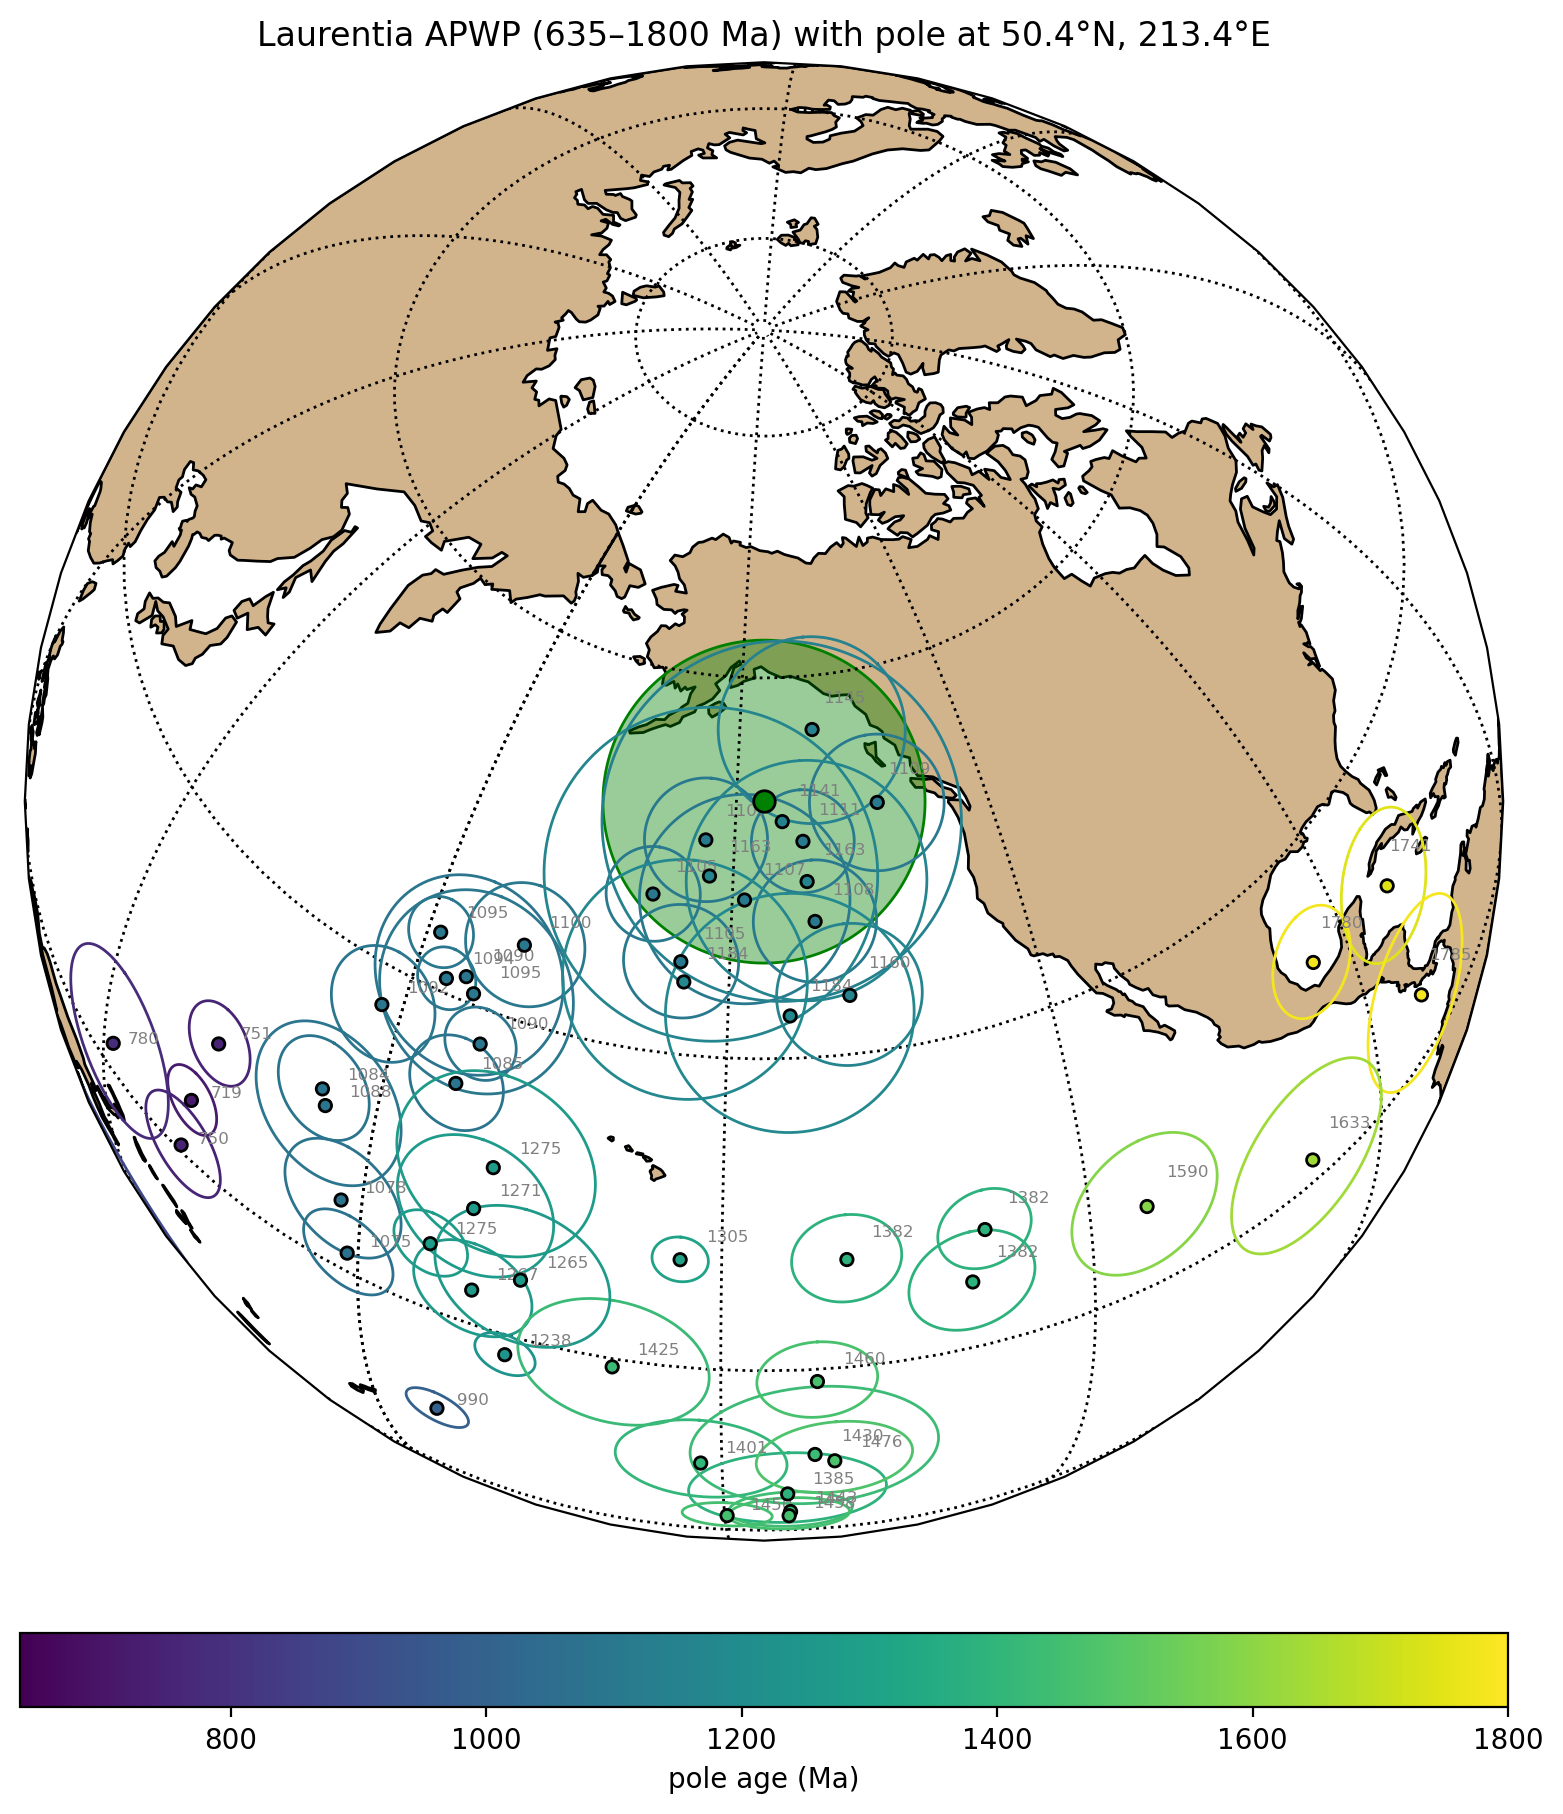

In [11]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

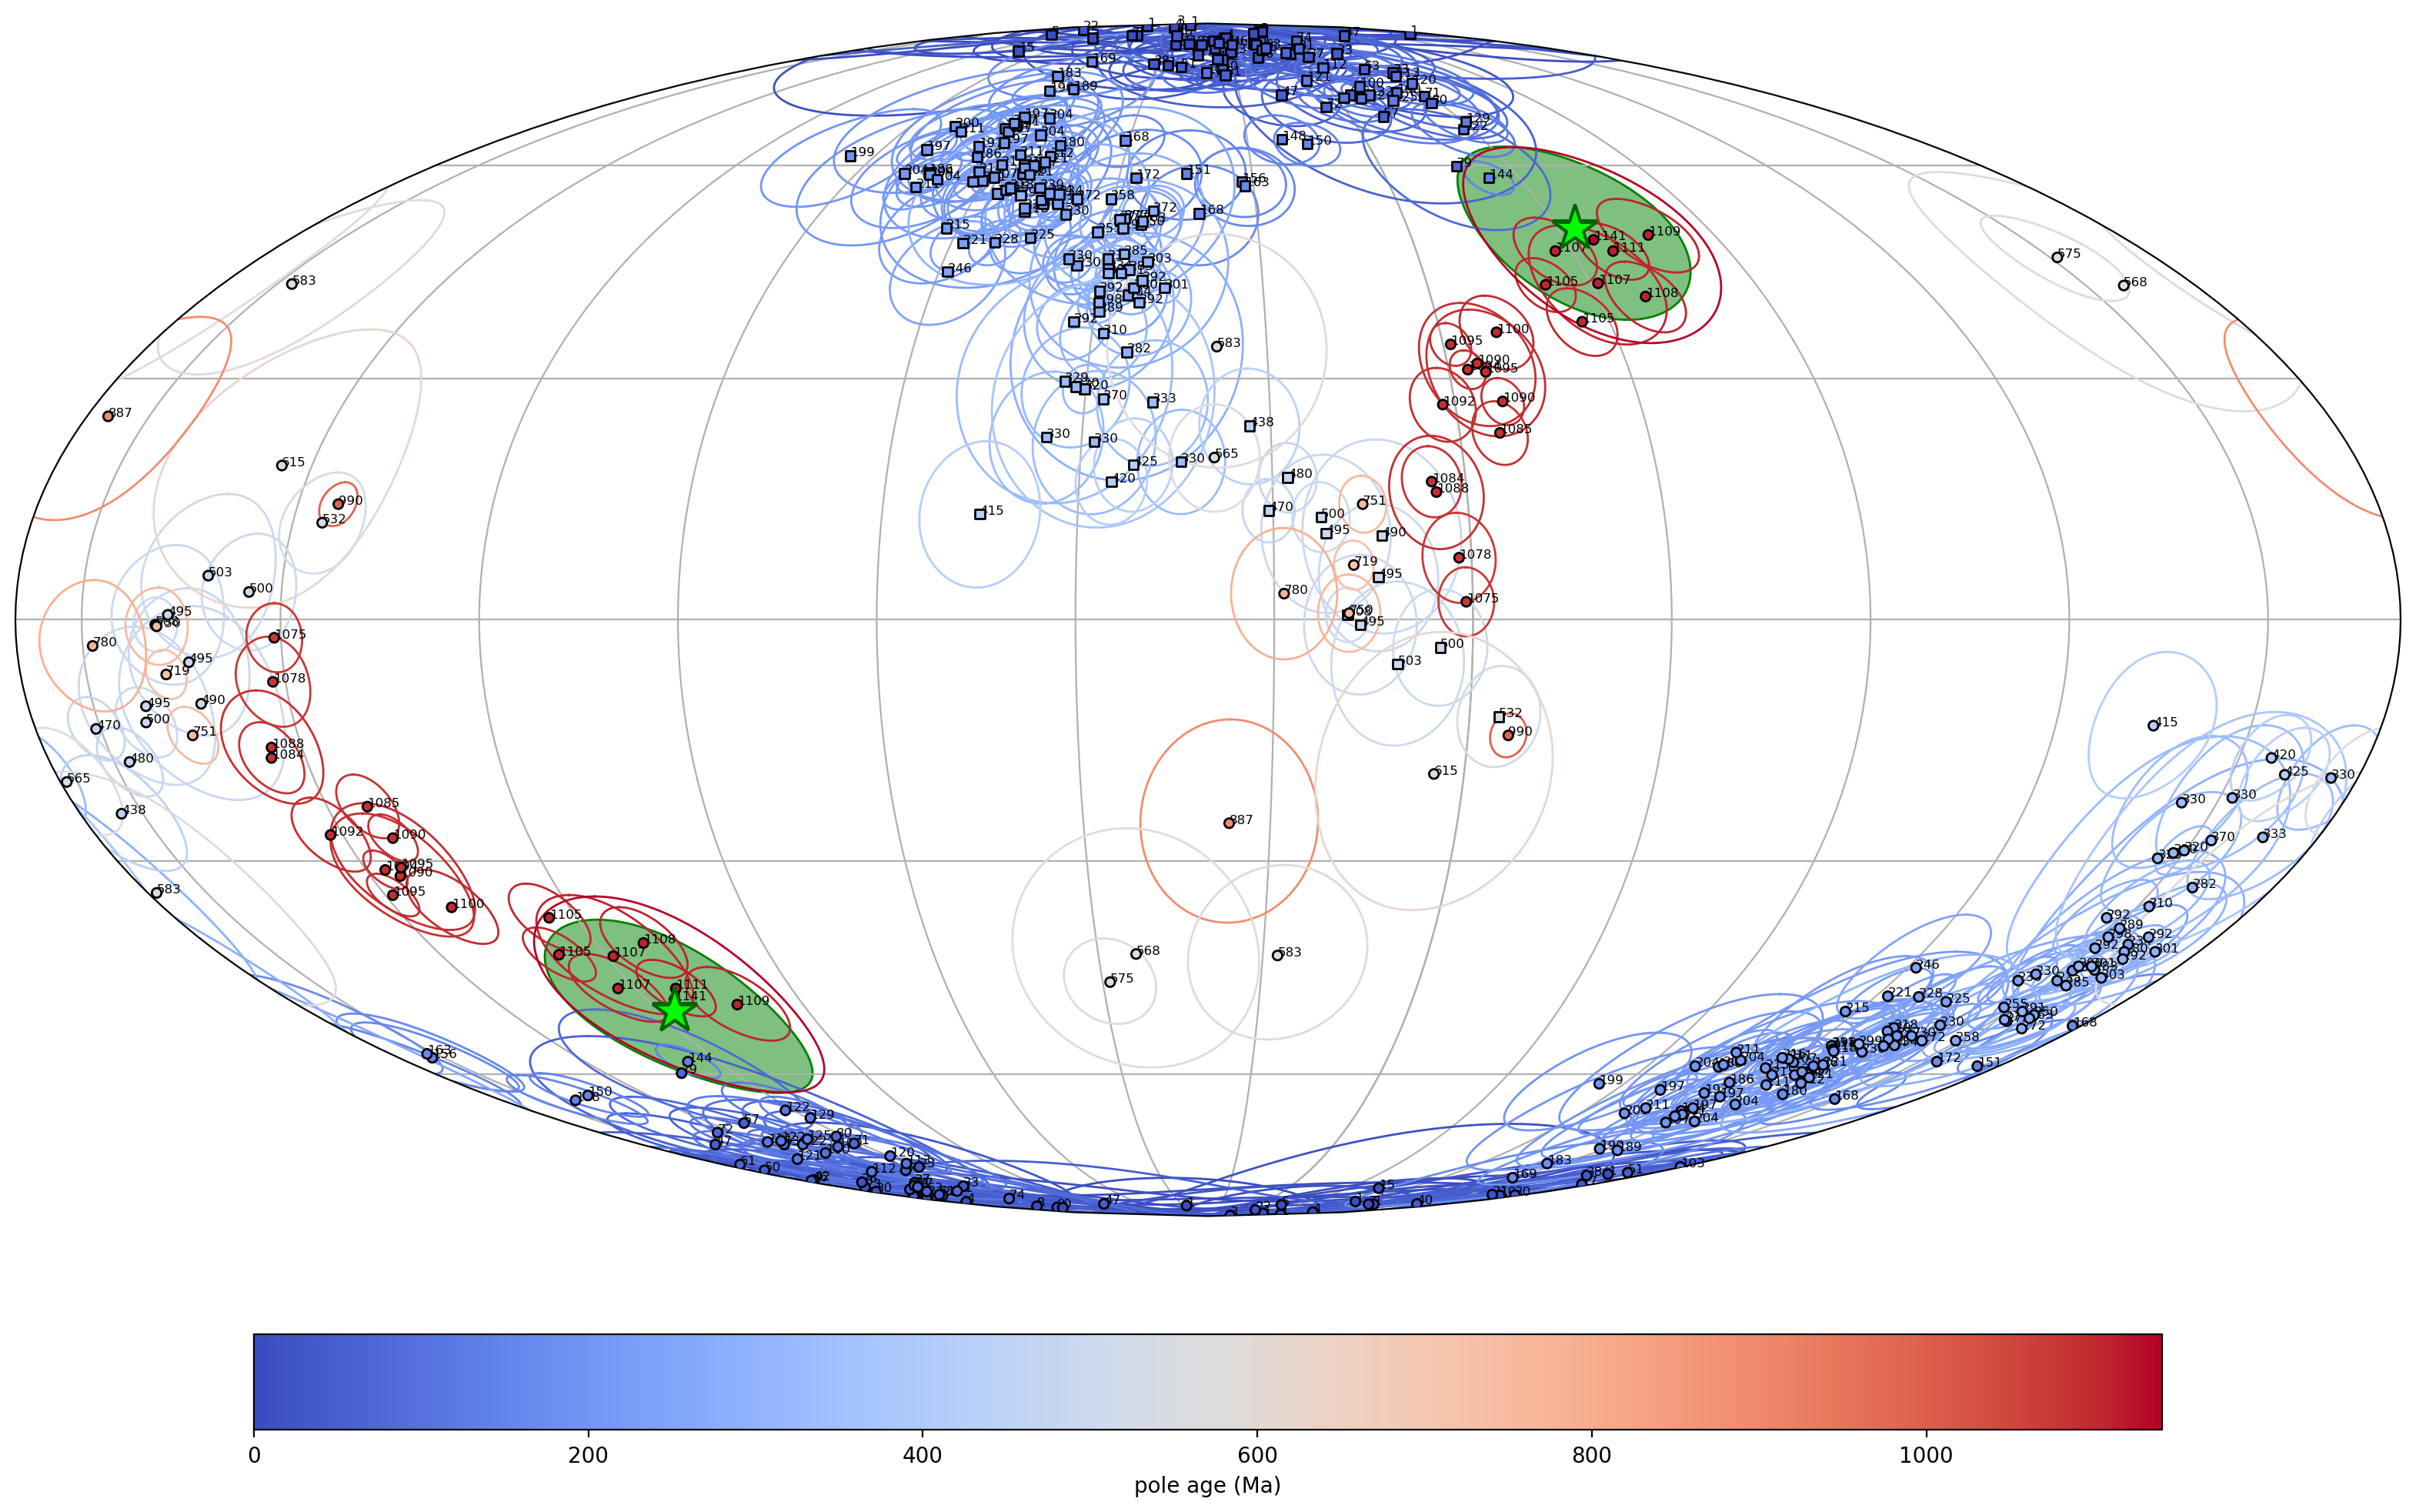

In [12]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Abitibi Dykes', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1141)
plt.show()

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | U-Pb baddeleyite 1140.6 ± 2 Ma (Krogh, 1987). |
| 2 | Techniques and statistical analysis | **0** | AF + thermal demagnetization with PCA, but only B = 8 dykes and A95 = 12.6° is large; Piispa et al. (2018) note the pole is derived from a limited number of independently cooled units and does not represent the time-averaged field, so paleosecular variation is marginally sampled. |
| 3 | Magnetic mineralogy characterized | **1** | Magnetite remanence characterized in the source study (Ernst & Buchan, 1993). |
| 4 | Field tests constrain age of magnetization | **C** | Positive baked-contact test (baked host margins carry the dyke direction; unbaked host differs). |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous southern Superior Province; vertical dykes need no tilt correction. |
| 6 | Presence of reversals | **1** | Mixed polarity (dykes A4 and A7 reversed); the reversal test is negative/indeterminate as the reversed directions are steeper than the normal group. |
| 7 | No resemblance to younger poles | **1** | Distinct from younger Laurentia poles. |
| | Total | **6/7** | Grade A |

## Nordic workshop summary

The Abitibi pole is recreated at the dyke level from the eight dyke means
(A3-A8 plus the new Halls et al. 2005 dyke SL13; A1 reassigned to the Biscotasing
swarm) of Ernst & Buchan (1993), with signed VGPs recomputed (the source carried
W/E-longitude and dp/dm errors). The recreation (50.4°N/213.4°E, A95 12.6°, N=8)
reproduces the Halls et al. (2005) / Piispa et al. (2018) modified pole
(50.5°N/213.8°E, A95 12.5°), which is offset ~8.5° from the original Ernst &
Buchan (1993) pole (GPMDB 7193). Positive baked-contact test (R4 = C) and mixed
polarity (R6 = 1); the limited number of cooling units keeps R2 = 0.

### Primary remanence pole

| Quantity | This study (site VGPs) | Ernst & Buchan (1993) | Previous Nordic compilation |
|---|---|---|---|
| Component | Primary ChRM (magnetite); mixed polarity | Primary ChRM; mean (normal dykes) | — |
| N (sites) | 8 | 5 | 7 |
| N (specimens) | 28 | — | 197 |
| Dec (°) | 297.9 | 291.5 | 295.0 |
| Inc (°) | 65.3 | 60.9 | 65.5 |
| k (direction) | 44.2 | 53 | 41.0 |
| α95 (direction, °) | 8.4 | 10.6 | 9.5 |
| Pole lat (°N) | 50.4 | 42.8 | 48.8 |
| Pole lon (°E) | 213.4 | 208.5 | 215.5 |
| A95 (°) | 12.6 | — | 14.1 |
| dp / dm (°) | — | 12.5 / 16.3 | 14.1 / 14.1 |


In [13]:
abitibi_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Abitibi Dykes',
    sites=dykes,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Primary characteristic remanent magnetization (magnetite); mixed polarity; eight-dyke modified mean of Halls et al. (2005)',
    tests='C+ (positive baked-contact test) and R (mixed polarity; dykes A4, A7 reversed, reversal test negative/indeterminate)',
    gpmdb_number='7193',
    percent_reversed=25,
    demag_code=4,
    R1=1, R2=0, R3=1, R4='C', R5=1, R6=1, R7=1, Grade='A',
    nominal_age=1141, lomagage=1139, himagage=1143,
    REF_method="A U-Pb baddeleyite age of 1140.6 ± 2 Ma (Krogh, 1987) dates the dykes.",
    POLE_AUTHORS='Ernst, R. E., & Buchan, K. L.',
    YEAR=1993,
    JOURNAL='Canadian Journal of Earth Sciences',
    VOLUME='30',
    VPAGES='1886-1897',
    TITLE='Paleomagnetism of the Abitibi dyke swarm, southern Superior Province, and implications for the Logan Loop',
    COMMENT='Eight dyke means are A3-A8 + SL13): the original A1 dyke is reassigned to the ca. 2167 Ma Biscotasing swarm and excluded, and the new normal-polarity dyke SL13 (direction/VGP from Piispa et al. 2018 Table 3, after Halls et al. 2005) is added. Reproduced in Swanson-Hysell et al., 2026.'
)
pt.save_nordic_summary(abitibi_summary, '1141_Abitibi')
abitibi_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Abitibi Dykes,GPMDB:7193,Primary characteristic remanent magnetization ...,C+ (positive baked-contact test) and R (mixed ...,0,48.0,279.0,8,28,...,1143,U-Pb baddeleyite age 1140.6 +/- 2 Ma on the Ab...,Abitibi Dykes,"Ernst, R. E., & Buchan, K. L.",1993,Canadian Journal of Earth Sciences,30,1886-1897,"Paleomagnetism of the Abitibi dyke swarm, sout...",Eight dyke means are A3-A8 + SL13): the origin...
